In [49]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_base1 = pd.read_csv("Result/free_recall_baseline_Katinka.csv")
df_base2 = pd.read_csv("Result/free_recall_baseline_Selma.csv")
df_base = pd.concat([df_base1, df_base2], ignore_index=True)
df_1A1 = pd.read_csv("Result/1A_Katinka.csv")
df_1A2 = pd.read_csv("Result/1A_Selma_20260908-162115.csv")
df_1A = pd.concat([df_1A1, df_1A2], ignore_index=True)
df_1B = pd.read_csv("Result/1B_Katinka.csv")
df_1B = pd.read_csv("Result/1B_Katinka.csv")
df_1C = pd.read_csv("Result/1C_Katinka.csv")
df_1C = pd.read_csv("Result/1C_Katinka.csv")


In [ ]:
def smooth_graph(graph_list):
    return [(graph_list[i] + graph_list[i-1] + graph_list[i+1])/3 for i in range(1,len(graph_list)-1)]

In [72]:
def prepare_trial_data(*dfs, trial_names=None, smooth=False):
    """
    Convert trial DataFrames into long format for Seaborn.

    Each DataFrame must contain a 'serial_position_score' column
    containing strings such as "0 1 0 0 1".
    """

    if trial_names is None:
        trial_names = [f"trial_{i+1}" for i in range(len(dfs))]

    if len(trial_names) != len(dfs):
        raise ValueError(
            "The number of trial names must match the number of DataFrames."
        )

    rows = []

    for df, trial_name in zip(dfs, trial_names):

        if "serial_position_score" not in df.columns:
            raise ValueError(
                f"DataFrame for '{trial_name}' must contain "
                "'serial_position_score'."
            )

        for scores in df["serial_position_score"]:

            # Convert "0 1 0 0 1" -> [0, 1, 0, 0, 1]
            scores = [int(x) for x in scores.split()]
            if smooth:
                scores = smooth_graph(scores)
            for x, y in enumerate(scores):
                rows.append({
                    "x": x,
                    "y": y,
                    "trial": trial_name
                })

    return pd.DataFrame(rows)

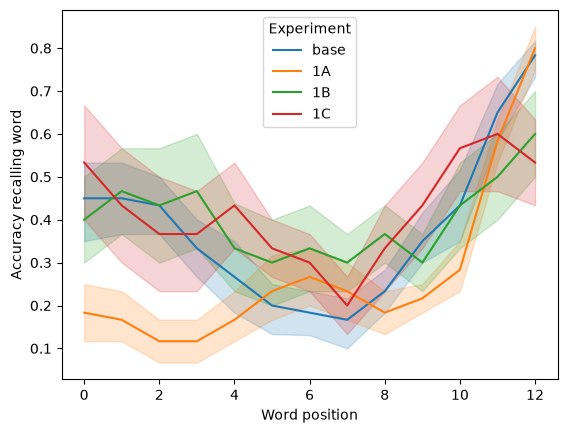

In [ ]:
df_plotdata = prepare_trial_data(df_base,df_1A,df_1B,df_1C, trial_names=["base","1A", "1B","1C"], smooth=True)

sns.lineplot(
    data=df_plotdata,
    x="x",
    y="y",
    hue="trial",       # separate curve for each event
    errorbar=("ci",70),     # confidence interval
    n_boot=1000
)

plt.xlabel("Word position")
plt.ylabel("Accuracy recalling word")
plt.legend(title="Experiment")
plt.show()

In [ ]:
def compute_position_score(df):
    # Convert each serial_position_score string into a list of integers
    scores = df["serial_position_score"].apply(
        lambda x: [int(v) for v in x.split()]
    )
    # Put all rows into a matrix
    score_matrix = pd.DataFrame(scores.tolist())

    # Mean at each position = proportion of correct recalls
    trialuracy_by_position = score_matrix.mean(axis=0)
    return score_matrix



In [19]:
def plot_accuracy_by_position(accuracy_by_position: list, legends: list):
    for i in range(len(accuracy_by_position)):
        plt.plot(
            range(1, len(accuracy_by_position[i]) + 1),
            accuracy_by_position[i],
            marker="o",
            label=legends[i]
        )

    plt.xlabel("Serial position")
    plt.ylabel("Proportion correct")
    plt.title("Recall accuracy by serial position")
    plt.xticks(range(1, len(accuracy_by_position[0]) + 1))
    plt.ylim(-0.1, 1.1)
    plt.grid(axis="y")
    plt.legend()
    plt.show()

In [ ]:
df_base = pd.read_csv("Result/free_recall_baseline_Katinka.csv")
trial_base = compute_position_score(df_base)
trial_base_smooth = smooth_graph(trial_base)

df_1A = pd.read_csv("Result/1A_Katinka.csv")
trial_1A = compute_position_score(df_1A)
trial_1A_smooth = smooth_graph(trial_1A)

df_1B = pd.read_csv("Result/1B_Katinka.csv")
trial_1B = compute_position_score(df_1B)
trial_1B_smooth = smooth_graph(trial_1B)

df_1C = pd.read_csv("Result/1C_Katinka.csv")
trial_1C = compute_position_score(df_1C)
trial_1C_smooth = smooth_graph(trial_1C)

plot_accuracy_by_position([trial_base, trial_1A, trial_1B, trial_1C], ["baseline", "1A", "1B", "1C"])
plot_accuracy_by_position([trial_base_smooth, trial_1A_smooth, trial_1B_smooth, trial_1C_smooth], ["baseline", "1A", "1B", "1C"])